In [1]:
import os
import sys

# Data processing
import numpy as np                              # import numpy
import pandas as pd

# Plotting
import matplotlib.pyplot as plt                 # import matplotlib

# Custom packages for simulation
# This works only if notebooks folder is in the "modules" parent folder
sys.path.insert(0, '..') # add modules folder (parent folder) into this notebook's path

# Institution modules
import institutions.dm_bargain as dm_bargain
import institutions.dm_travel as dm_travel

# Environment modules
import environment.dm_agents as dm_agents
import environment.dm_env as env
import environment.env_make_agents as env_make_agents

# Simulation modules
import simulations.dm_sim_period as simulate
import simulations.dm_sim as dm_sim

# Import functions to run experiments
import simulations.dm_sim_experiment as dm_sim_experiment

# Utility modules
import utils.dm_utils as dm_utils
import utils.dm_process_results as dm_process_results
import utils.dm_res_helpers as dm_res_helpers # Extended results module
import utils.dm_stats as dm_stat

# Import notebook helper functions
import utils.nb_helpers as nb_helpers

# Stats models
from scipy.stats import sem

import copy

!
{'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}
!
{'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}
!
{'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}
!
{'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}
!
{'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}
!
{'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}
!
{'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}
!
{'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}
!
{'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}
!
{'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}
?
{'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}
?
{'reset_flag_freque

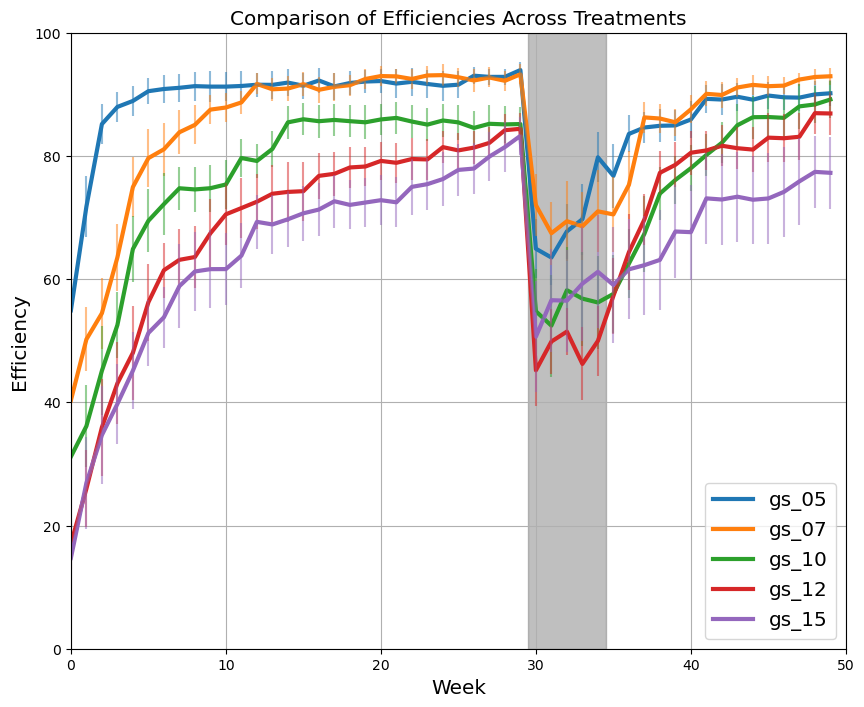

In [4]:
agent_num = 5
lower_bound = 200 
upper_bound = 600
num_units = 8
endows = [500, 0]
move_error_rate = 0
starting_location = None
agent_class = 'ZIDPA'

# Define the strategy parameters as a dictionary
strategy_params = {'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 7
                   }

buy_group = [agent_num, 'BUYER', agent_class, strategy_params, lower_bound, upper_bound, num_units, endows[0], 'utility', move_error_rate, starting_location]

sell_group = [agent_num, 'SELLER', agent_class, strategy_params, lower_bound, upper_bound, num_units, endows[1], 'profit', move_error_rate, starting_location]

agent_groups = [buy_group, sell_group]


num_trials = 10

event_begin = 30
event_end = 35

mc_params = {
        'sim_name': "test_grid_size",
        'num_trials': 10,
        'num_weeks': 50,
        'num_periods': 7,
        'num_rounds': 5,
        'num_traders': 10,
        'agent_groups': agent_groups,
        'grid_size': 15,
        'event_begin': event_begin,
        'event_end': event_end,
        'new_agent_class': 'ZIDPR',
        'new_strategy_params': None,
        'new_movement_error_rate': None,
        'group_names': None
}

mc_treats = {
    'gs_05': {'grid_size':5},
    'gs_07': {'grid_size':7},
    'gs_10': {'grid_size':10},
    'gs_12': {'grid_size':12},
    'gs_15': {'grid_size':15},
}


dir_try = dm_sim_experiment.make_experiment(sim_vars=mc_params, 
                                  treatment_dict=mc_treats, treatment_names=list(mc_treats), 
                                  return_period_df=False, includes_event=True)

exp2_eff, exp_class, exp_group = dm_utils.summary_surplus(dir_try)
dm_utils.plot_comp_efficiencies(exp2_eff, shadow=True, event_bars=(event_begin, event_end))

Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None]]
Moving to: [['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 0], ['ZIDP

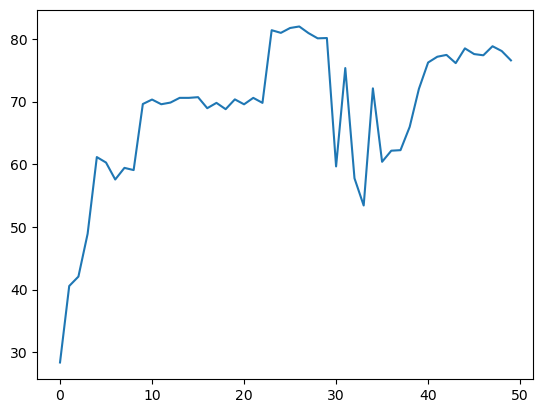

In [2]:
# Define inputs
sim_name = "event_sim_example"
num_weeks = 50
num_periods = 7
num_rounds = 5

num_traders = 20
# Agent Groups
agent_num = 10
lower_bound = 200 
upper_bound = 600
num_units = 8
endows = [500, 0]
move_error_rate = 0
starting_location = None
agent_class = 'ZIDPA'

# Define the strategy parameters as a dictionary
strategy_params = {'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 7
                   }

buy_group = [agent_num, 'BUYER', agent_class, strategy_params, lower_bound, upper_bound, num_units, endows[0], 'utility', move_error_rate, starting_location]

sell_group = [agent_num, 'SELLER', agent_class, strategy_params, lower_bound, upper_bound, num_units, endows[1], 'profit', move_error_rate, starting_location]

agent_groups = [buy_group, sell_group]

grid_size = 15

# Define the weeks when the event will happen
event_begin = 30
event_end = 35

# run an event simulation
sim_data0 = dm_sim_experiment.make_event_sim(sim_name, 
                   num_weeks, num_periods, num_rounds,
                   num_traders, agent_groups, grid_size,
                   event_begin, event_end)

weeks_eff = np.zeros(num_weeks)
for i in range(num_weeks):
    weeks_eff[i] = sim_data0[i]['eff']

plt.plot(weeks_eff)

Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None]]
Moving to: [['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 14}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 14}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 14}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 14}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 14}, 0], [

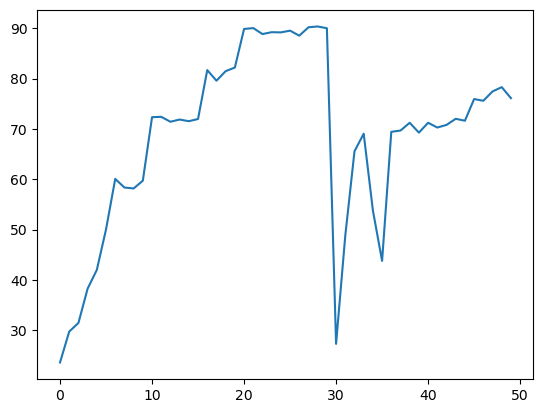

In [3]:
# Define the strategy parameters as a dictionary
strategy_params.update({'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 14
                   })

# run an event simulation
sim_data1 = dm_sim_experiment.make_event_sim(sim_name, 
                   num_weeks, num_periods, num_rounds,
                   num_traders, agent_groups, grid_size,
                   event_begin, event_end)

weeks_eff = np.zeros(num_weeks)
for i in range(num_weeks):
    weeks_eff[i] = sim_data1[i]['eff']

plt.plot(weeks_eff)

Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None]]
Moving to: [['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 21}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 21}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 21}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 21}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 21}, 0], [

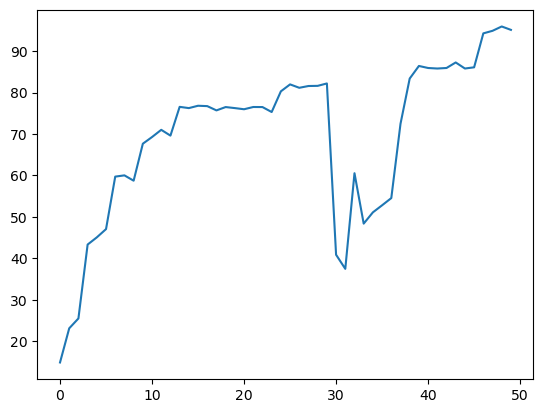

In [4]:
# Define the strategy parameters as a dictionary
strategy_params.update({'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 21
                   })

# run an event simulation
sim_data2 = dm_sim_experiment.make_event_sim(sim_name, 
                   num_weeks, num_periods, num_rounds,
                   num_traders, agent_groups, grid_size,
                   event_begin, event_end)

weeks_eff = np.zeros(num_weeks)
for i in range(num_weeks):
    weeks_eff[i] = sim_data2[i]['eff']

plt.plot(weeks_eff)

Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None]]
Moving to: [['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 5}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 5}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 5}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 5}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 5}, 0], ['ZIDP

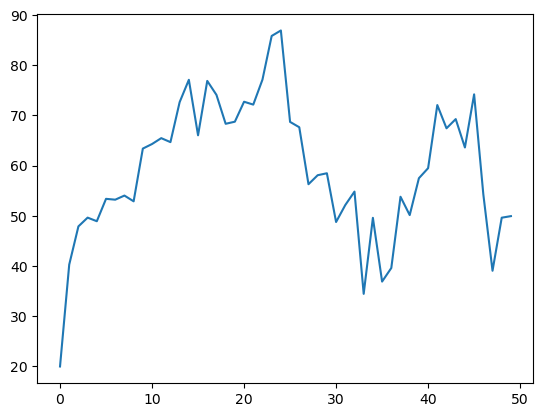

In [5]:
# Define the strategy parameters as a dictionary
strategy_params.update({'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 5
                   })

# run an event simulation
sim_data3 = dm_sim_experiment.make_event_sim(sim_name, 
                   num_weeks, num_periods, num_rounds,
                   num_traders, agent_groups, grid_size,
                   event_begin, event_end)

weeks_eff = np.zeros(num_weeks)
for i in range(num_weeks):
    weeks_eff[i] = sim_data3[i]['eff']

plt.plot(weeks_eff)

Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None]]
Moving to: [['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 3, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 3, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 3, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 3, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 3, 'reset_flag_window': 7}, 0], ['ZIDP

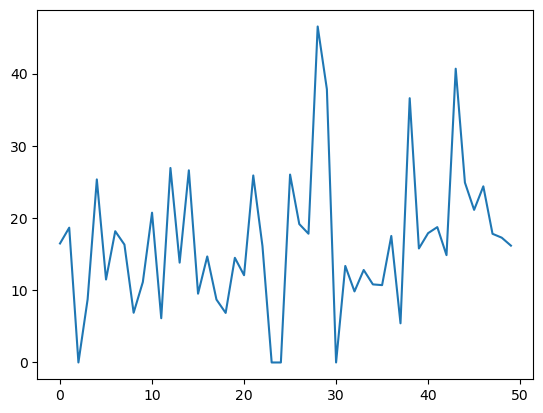

In [6]:
# Define the strategy parameters as a dictionary
strategy_params.update({'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 3,
                   'reset_flag_window': 7
                   })

# run an event simulation
sim_data4 = dm_sim_experiment.make_event_sim(sim_name, 
                   num_weeks, num_periods, num_rounds,
                   num_traders, agent_groups, grid_size,
                   event_begin, event_end)

weeks_eff = np.zeros(num_weeks)
for i in range(num_weeks):
    weeks_eff[i] = sim_data4[i]['eff']

plt.plot(weeks_eff)

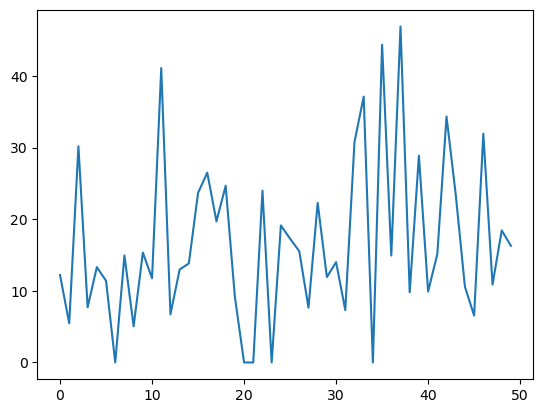

In [7]:
# Define the strategy parameters as a dictionary
strategy_params.update({'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 6,
                   'reset_flag_window': 14
                   })

# run an event simulation
sim_data5 = dm_sim_experiment.make_event_sim(sim_name, 
                   num_weeks, num_periods, num_rounds,
                   num_traders, agent_groups, grid_size,
                   event_begin, event_end)

weeks_eff = np.zeros(num_weeks)
for i in range(num_weeks):
    weeks_eff[i] = sim_data5[i]['eff']

plt.plot(weeks_eff)

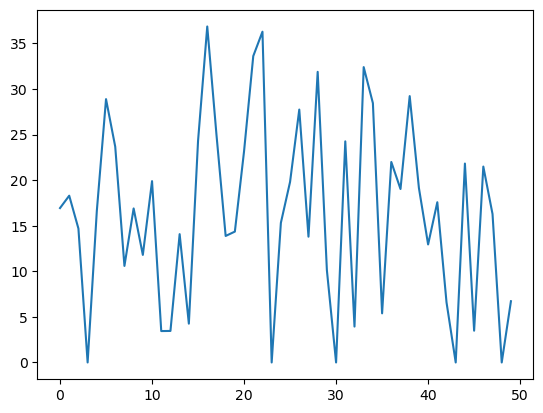

In [8]:
# Define the strategy parameters as a dictionary
strategy_params.update({'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 9,
                   'reset_flag_window': 21
                   })

# run an event simulation
sim_data6 = dm_sim_experiment.make_event_sim(sim_name, 
                   num_weeks, num_periods, num_rounds,
                   num_traders, agent_groups, grid_size,
                   event_begin, event_end)

weeks_eff = np.zeros(num_weeks)
for i in range(num_weeks):
    weeks_eff[i] = sim_data6[i]['eff']

plt.plot(weeks_eff)

In [7]:
# Define the strategy parameters as a dictionary
strategy_params.update({'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 2,
                   'reset_flag_window': 7
                   })

num_trials = 10

mc_params = {
        'sim_name': sim_name,
        'num_trials': num_trials,
        'num_weeks': num_weeks,
        'num_periods': num_periods,
        'num_rounds': num_rounds,
        'num_traders': num_traders,
        'agent_groups': agent_groups,
        'grid_size': grid_size,
        'event_begin': event_begin,
        'event_end': event_end,
        'new_agent_class': 'ZIDPR',
        'new_strategy_params': None,
        'new_movement_error_rate': None,
        'group_names': None
}

mc_df = dm_sim_experiment.make_event_monte_carlo(
                           return_df=True, return_period_df=False,
                           passed_as_dict=True, params_dict=mc_params)

Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None]]
Moving to: [['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 7}, 0], ['ZIDP

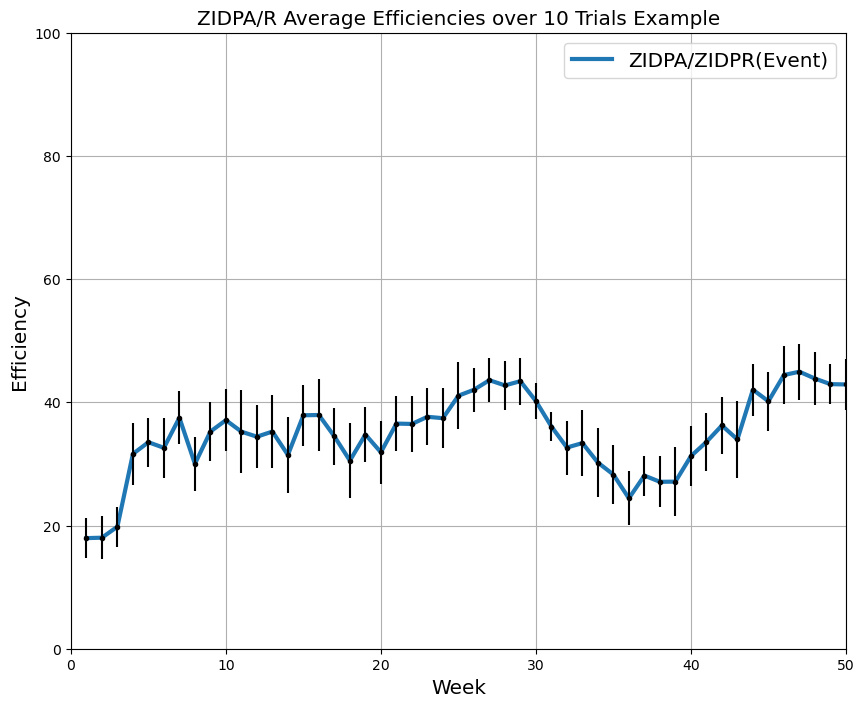

In [8]:
dm_utils.draw_efficiency(mc_df, labels='ZIDPA/ZIDPR(Event)', title=f'ZIDPA/R Average Efficiencies over {num_trials} Trials Example')

In [9]:
mc_evx = dm_sim_experiment.make_event_monte_carlo(
                           return_df=False, return_period_df=False,
                           passed_as_dict=True, params_dict=mc_params)

Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None]]
Moving to: [['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 7}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 7}, 0], ['ZIDP

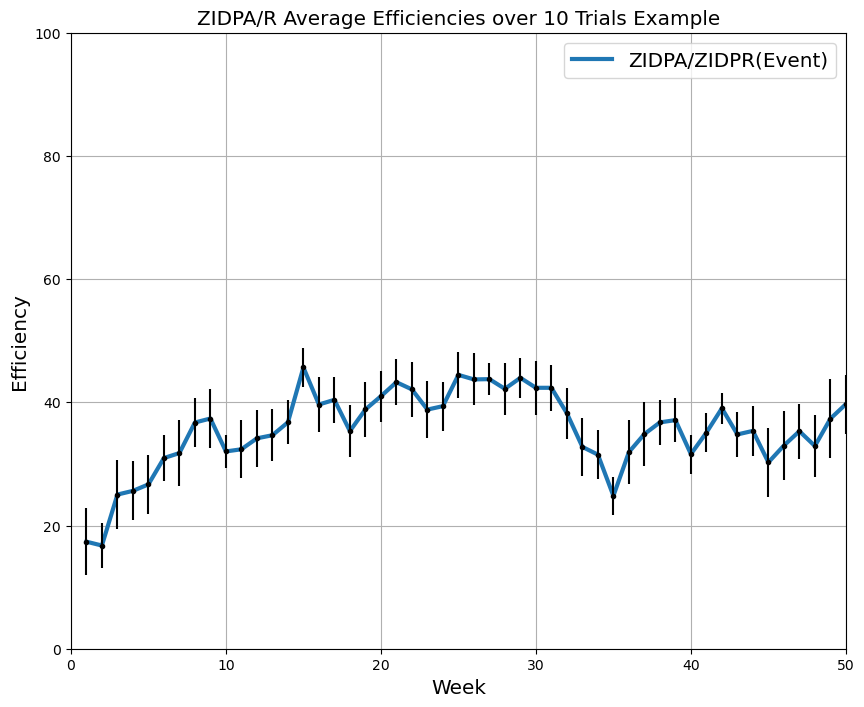

In [10]:
dm_utils.draw_efficiency(mc_evx, labels='ZIDPA/ZIDPR(Event)', title=f'ZIDPA/R Average Efficiencies over {num_trials} Trials Example')

In [11]:
# Test Event Experiment, two ways
# Define the strategy parameters as a dictionary
strategy_params.update({'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 7,
                   'reset_flag_window': 3
                   })

num_trials = 10

mc_params = {
        'sim_name': sim_name,
        'num_trials': num_trials,
        'num_weeks': num_weeks,
        'num_periods': num_periods,
        'num_rounds': num_rounds,
        'num_traders': num_traders,
        'agent_groups': agent_groups,
        'grid_size': grid_size,
        'event_begin': event_begin,
        'event_end': event_end,
        'new_agent_class': 'ZIDPR',
        'new_strategy_params': None,
        'new_movement_error_rate': None,
        'group_names': None
}

mc_treats = {
    'gs_05': {'grid_size':5},
    'gs_07': {'grid_size':7},
    'gs_10': {'grid_size':10},
    'gs_12': {'grid_size':12},
    'gs_15': {'grid_size':15},
}


dir_try = dm_sim_experiment.make_experiment(sim_vars=mc_params, 
                                  treatment_dict=mc_treats, treatment_names=list(mc_treats), 
                                  return_period_df=False, includes_event=True)

wrap_try = dm_sim_experiment.make_event_experiment(sim_vars=mc_params, 
                                  treatment_dict=mc_treats, treatment_names=list(mc_treats), 
                                  return_period_df=False)

Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None]]
Moving to: [['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 7, 'reset_flag_window': 3}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 7, 'reset_flag_window': 3}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 7, 'reset_flag_window': 3}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 7, 'reset_flag_window': 3}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 7, 'reset_flag_window': 3}, 0], ['ZIDP

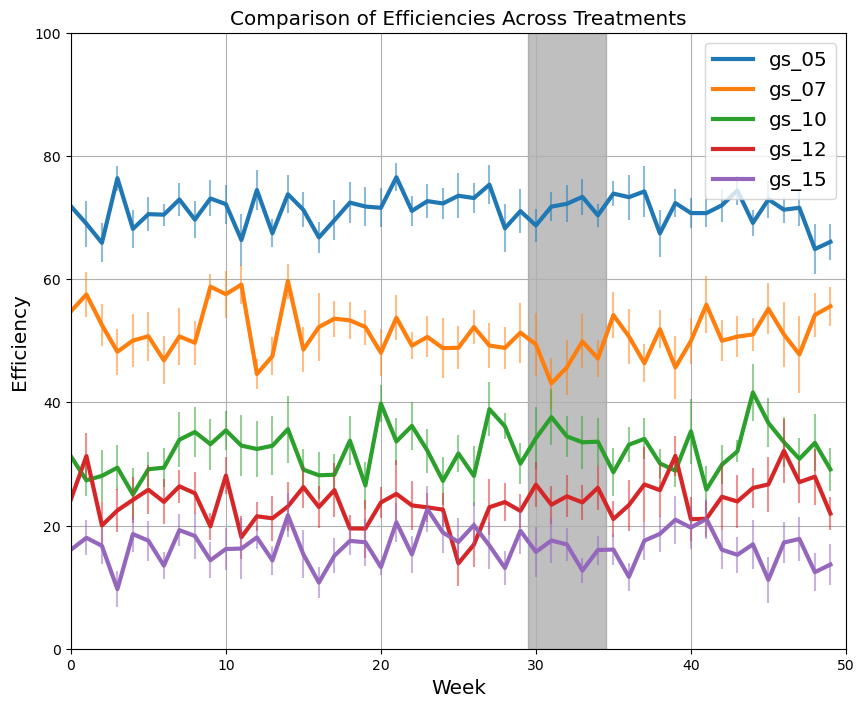

In [12]:
exp_eff, exp_class, exp_group = dm_utils.summary_surplus(dir_try)
dm_utils.plot_comp_efficiencies(exp_eff, shadow=True, event_bars=(event_begin, event_end))

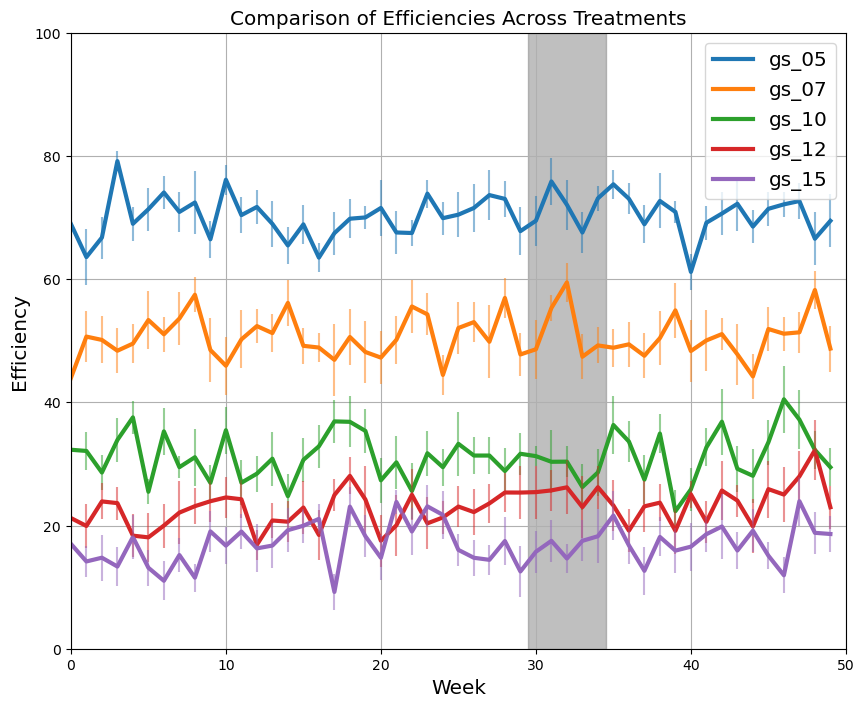

In [17]:
exp2_eff, exp_class, exp_group = dm_utils.summary_surplus(wrap_try)
dm_utils.plot_comp_efficiencies(exp2_eff, shadow=True, event_bars=(event_begin, event_end))

In [13]:
agent_num = 5
lower_bound = 200 
upper_bound = 600
num_units = 8
endows = [500, 0]
move_error_rate = 0
starting_location = None
agent_class = 'ZIDPA'

buy_group = [agent_num, 'BUYER', agent_class, None, lower_bound, upper_bound, num_units, endows[0], 'utility', move_error_rate, starting_location]

sell_group = [agent_num, 'SELLER', agent_class, None, lower_bound, upper_bound, num_units, endows[1], 'profit', move_error_rate, starting_location]

agent_groups = [buy_group, sell_group]

mc_params = {
        'sim_name': "ag_mc_test",
        'num_trials': 10,
        'num_weeks': 10,
        'num_periods': 7,
        'num_rounds': 5,
        'num_traders': 10,
        'agent_groups': agent_groups,
        'grid_size': 15,
        'event_begin': 7,
        'event_end': 8,
        'new_agent_class': 'ZIDPR',
        'new_strategy_params': None,
        'new_movement_error_rate': None,
        'group_names': None
}

treats = {
    't7_3':{'strategy_params': {'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 7,
                   'reset_flag_window': 3
    }},
    't3_1':{'strategy_params': {'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 3,
                   'reset_flag_window': 1
    }}}


df_data = dm_sim_experiment.make_agent_experiment(mc_params, treats, includes_event=True)

Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None]]
Moving to: [['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 3, 'reset_flag_window': 1}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 3, 'reset_flag_window': 1}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 3, 'reset_flag_window': 1}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 3, 'reset_flag_window': 1}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 3, 'reset_flag_window': 1}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 3, 'reset_flag_window': 1}, 0], ['ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 3, 'reset_flag_window': 1}, 0], ['ZIDPA', {'reset_flag_frequency

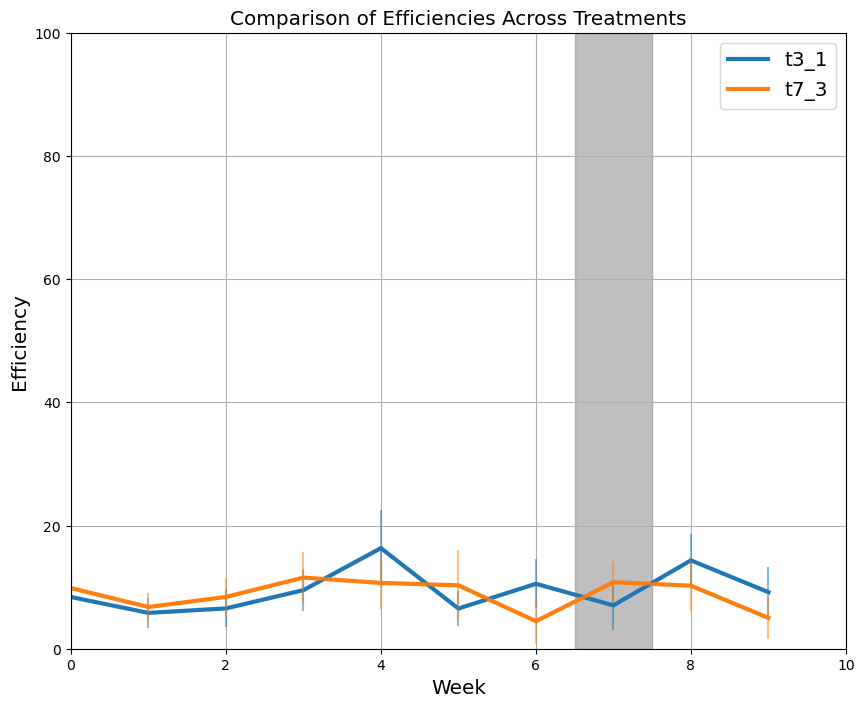

In [14]:
exp2_eff, exp_class, exp_group = dm_utils.summary_surplus(df_data)
dm_utils.plot_comp_efficiencies(exp2_eff, shadow=True, event_bars=(7, 8))

None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None


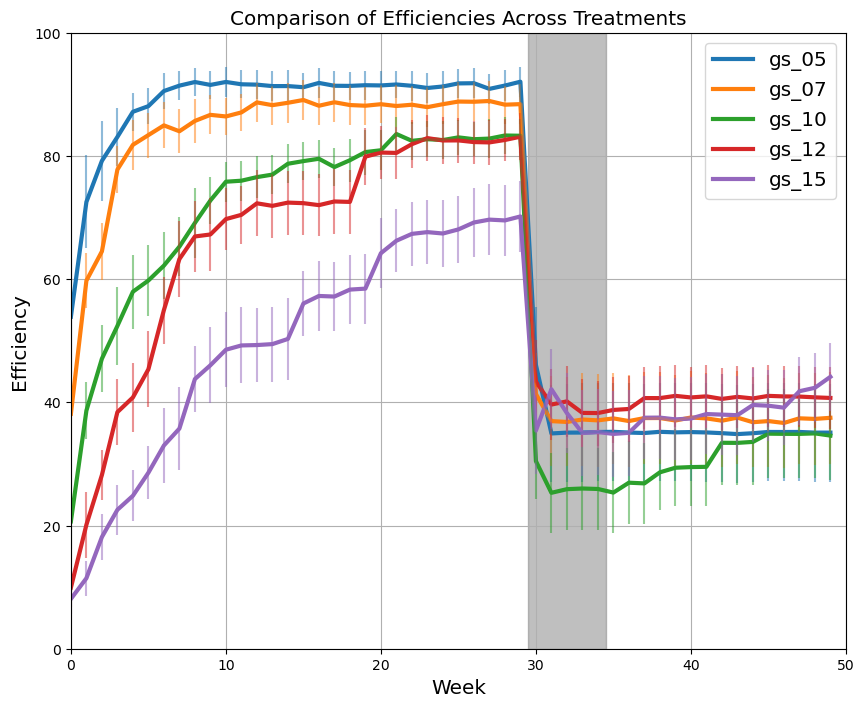

In [4]:
agent_num = 5
lower_bound = 200 
upper_bound = 600
num_units = 8
endows = [500, 0]
move_error_rate = 0
starting_location = None
agent_class = 'ZIDPA'

buy_group = [agent_num, 'BUYER', agent_class, None, lower_bound, upper_bound, num_units, endows[0], 'utility', move_error_rate, starting_location]

sell_group = [agent_num, 'SELLER', agent_class, None, lower_bound, upper_bound, num_units, endows[1], 'profit', move_error_rate, starting_location]

agent_groups = [buy_group, sell_group]

# Test Event Experiment, two ways
# Define the strategy parameters as a dictionary
strategy_params = {'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 3,
                   'reset_flag_window': 7
                   }

num_trials = 10

event_begin = 30
event_end = 35

mc_params = {
        'sim_name': "test_grid_size",
        'num_trials': 10,
        'num_weeks': 50,
        'num_periods': 7,
        'num_rounds': 5,
        'num_traders': 10,
        'agent_groups': agent_groups,
        'grid_size': 15,
        'event_begin': event_begin,
        'event_end': event_end,
        'new_agent_class': 'ZIDPR',
        'new_strategy_params': None,
        'new_movement_error_rate': None,
        'group_names': None
}

mc_treats = {
    'gs_05': {'grid_size':5},
    'gs_07': {'grid_size':7},
    'gs_10': {'grid_size':10},
    'gs_12': {'grid_size':12},
    'gs_15': {'grid_size':15},
}


dir_try = dm_sim_experiment.make_experiment(sim_vars=mc_params, 
                                  treatment_dict=mc_treats, treatment_names=list(mc_treats), 
                                  return_period_df=False, includes_event=True)

exp2_eff, exp_class, exp_group = dm_utils.summary_surplus(dir_try)
dm_utils.plot_comp_efficiencies(exp2_eff, shadow=True, event_bars=(event_begin, event_end))

Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None]]
Moving to: [['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0]]
Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None]]
Moving to: [['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0], ['ZIDPA', None, 0]]
Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', N

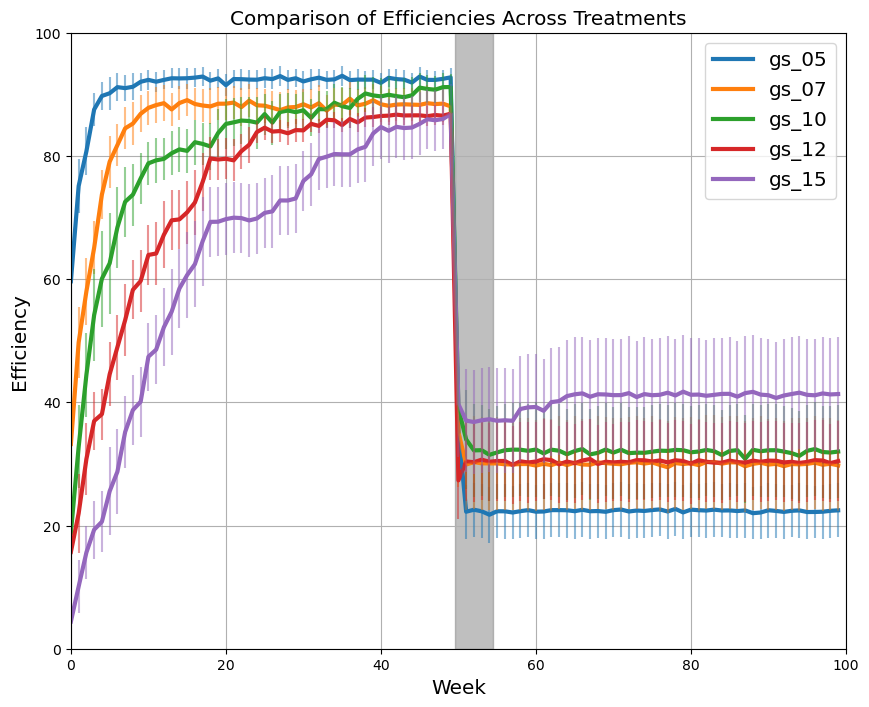

In [22]:
mc_params.update({'num_weeks': 100, 'event_begin': 50, 'event_end': 55})

dir_try = dm_sim_experiment.make_experiment(sim_vars=mc_params, 
                                  treatment_dict=mc_treats, treatment_names=list(mc_treats), 
                                  return_period_df=False, includes_event=True)

exp2_eff, exp_class, exp_group = dm_utils.summary_surplus(dir_try)
dm_utils.plot_comp_efficiencies(exp2_eff, shadow=True, event_bars=(50, 55))



Running event simulation with params: ['event_sim_example', 50, 7, 5, 20, [[10, 'BUYER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, 500, 'utility', 0, None], [10, 'SELLER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, 0, 'profit', 0, None]], 15, None, 30, 35, 1, 'ZIDPR', None, None]


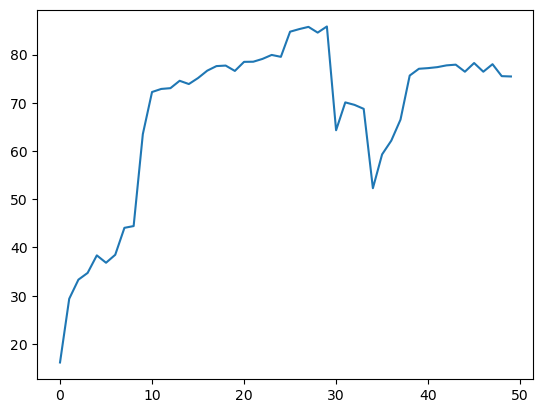

In [2]:
# Define inputs
sim_name = "event_sim_example"
num_weeks = 50
num_periods = 7
num_rounds = 5

num_traders = 20
# Agent Groups
agent_num = 10
lower_bound = 200 
upper_bound = 600
num_units = 8
endows = [500, 0]
move_error_rate = 0
starting_location = None
agent_class = 'ZIDPA'

# Define the strategy parameters as a dictionary
strategy_params = {'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 7
                   }

buy_group = [agent_num, 'BUYER', agent_class, strategy_params, lower_bound, upper_bound, num_units, endows[0], 'utility', move_error_rate, starting_location]

sell_group = [agent_num, 'SELLER', agent_class, strategy_params, lower_bound, upper_bound, num_units, endows[1], 'profit', move_error_rate, starting_location]

agent_groups = [buy_group, sell_group]

grid_size = 15

# Define the weeks when the event will happen
event_begin = 30
event_end = 35

# run an event simulation
sim_data0 = dm_sim_experiment.make_event_sim(sim_name, 
                   num_weeks, num_periods, num_rounds,
                   num_traders, agent_groups, grid_size,
                   event_begin, event_end, print_params=True)

weeks_eff = np.zeros(num_weeks)
for i in range(num_weeks):
    weeks_eff[i] = sim_data0[i]['eff']

plt.plot(weeks_eff)

Running experiment with sim_vars: {'sim_name': 'event_sim_example', 'num_trials': 10, 'num_weeks': 50, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 20, 'agent_groups': [[10, 'BUYER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, 500, 'utility', 0, None], [10, 'SELLER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, 0, 'profit', 0, None]], 'grid_size': 15, 'event_begin': 30, 'event_end': 35, 'new_agent_class': 'ZIDPR', 'new_strategy_params': None, 'new_movement_error_rate': None, 'group_names': None}, treatment_vars: {'gs_05': {'grid_size': 5}, 'gs_07': {'grid_size': 7}, 'gs_10': {'grid_size': 10}, 'gs_12': {'grid_size': 12}, 'gs_15': {'grid_size': 15}}, for treatments: ['gs_05', 'gs_07', 'gs_10', 'gs_12', 'gs_15'].


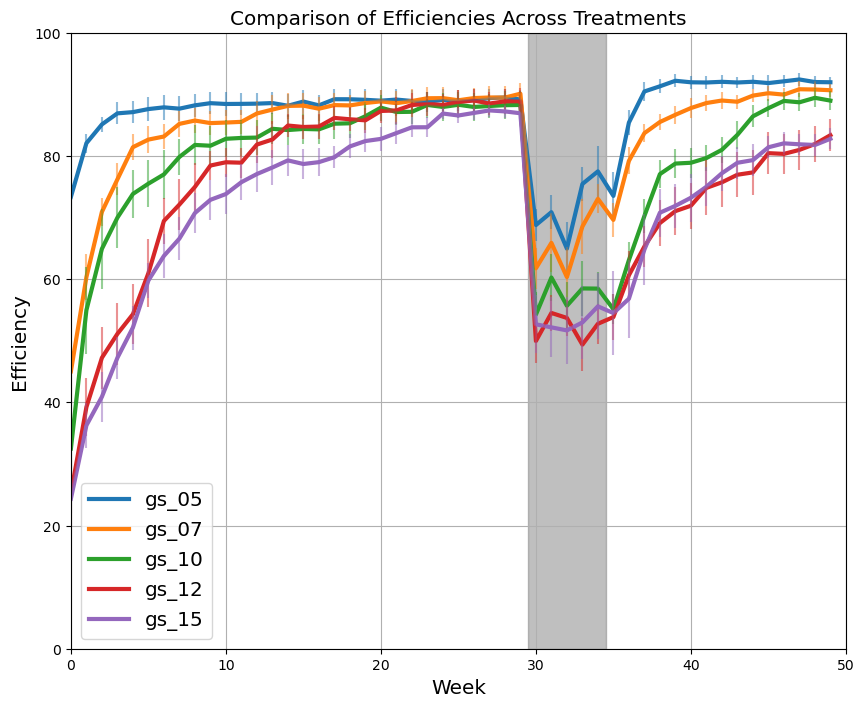

In [4]:
# Test Event Experiment, two ways
# Define the strategy parameters as a dictionary
strategy_params.update({'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 7
                   })

num_trials = 10

mc_params = {
        'sim_name': sim_name,
        'num_trials': num_trials,
        'num_weeks': num_weeks,
        'num_periods': num_periods,
        'num_rounds': num_rounds,
        'num_traders': num_traders,
        'agent_groups': agent_groups,
        'grid_size': grid_size,
        'event_begin': event_begin,
        'event_end': event_end,
        'new_agent_class': 'ZIDPR',
        'new_strategy_params': None,
        'new_movement_error_rate': None,
        'group_names': None
}

mc_treats = {
    'gs_05': {'grid_size':5},
    'gs_07': {'grid_size':7},
    'gs_10': {'grid_size':10},
    'gs_12': {'grid_size':12},
    'gs_15': {'grid_size':15},
}


dir_try = dm_sim_experiment.make_experiment(sim_vars=mc_params, 
                                  treatment_dict=mc_treats, treatment_names=list(mc_treats), 
                                  return_period_df=False, includes_event=True, print_params=True)

exp2_eff, exp_class, exp_group = dm_utils.summary_surplus(dir_try)
dm_utils.plot_comp_efficiencies(exp2_eff, shadow=True, event_bars=(event_begin, event_end))

{'win14': [[10, 'BUYER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 14}, 200, 600, 8, (500, 0), None, 0, None], [10, 'SELLER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 14}, 200, 600, 8, (500, 0), None, 0, None]], 'win07': [[10, 'BUYER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, (500, 0), None, 0, None], [10, 'SELLER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, (500, 0), None, 0, None]]}
Running experiment with sim_vars: {'sim_name': 'test_agent_event_exp', 'num_trials': 10, 'num_weeks': 50, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 20, 'agent_groups': [[10, 'BUYER', 'ZIDPA', None, 200, 600, 8, (500, 0), None, 0, None], [10, 'SELLER', 'ZIDPA', None, 200, 600, 8, (500, 0), None, 0, None]], 'grid_size': 10, 'event_begin': 30, 'event_end': 35, 'new_

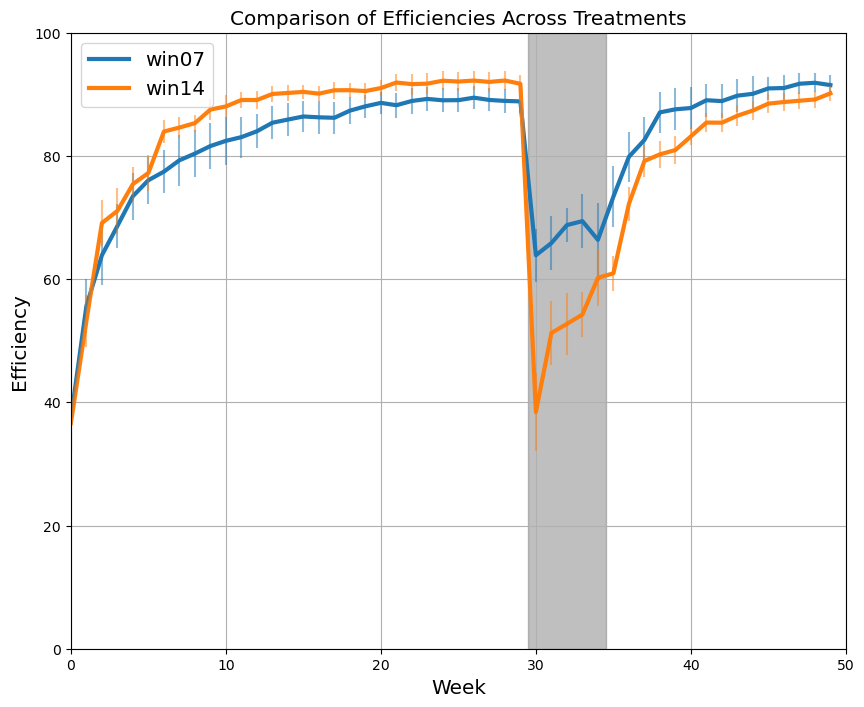

In [4]:
# Test Agent Event Experiment, two ways

# Define base agent groups for experiment
base_groups, group_names = dm_utils.gen_agent_groups(num_agents=10, 
                          agent_type=['BUYER', 'SELLER'],
                          agent_class='ZIDPA', 
                          strategy_params=None,
                          lower_bound=200, 
                          upper_bound=600, 
                          num_units=8, 
                          endowment=(500, 0), 
                          payoff_function=None, 
                          move_error_rate=0, 
                          starting_location=None, 
                          return_names=True)

# Define the strategy parameters as a dictionary
strategy_params14 = {'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 14
                   }

strategy_params7 = {'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 7
                   }

num_trials = 10
event_begin = 30
event_end = 35

mc_params = {
        'sim_name': 'test_agent_event_exp',
        'num_trials': num_trials,
        'num_weeks': 50,
        'num_periods': 7,
        'num_rounds': 5,
        'num_traders': 20,
        'agent_groups': base_groups,
        'grid_size': 10,
        'event_begin': event_begin,
        'event_end': event_end,
        'new_agent_class': 'ZIDPR',
        'new_strategy_params': None,
        'new_movement_error_rate': None,
        'group_names': group_names
}

mc_treats = {
    'win14': {'strategy_params':strategy_params14},
    'win07': {'strategy_params':strategy_params7},
}


dir_try = dm_sim_experiment.make_experiment(sim_vars=mc_params, 
                                  treatment_dict=mc_treats, treatment_names=list(mc_treats), 
                                  return_period_df=False, includes_event=True, print_params=True)

exp2_eff, exp_class, exp_group = dm_utils.summary_surplus(dir_try)
dm_utils.plot_comp_efficiencies(exp2_eff, shadow=True, event_bars=(event_begin, event_end))

{'win14_2': [[10, 'BUYER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 14}, 200, 600, 8, (500, 0), None, 0, None], [10, 'SELLER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 14}, 200, 600, 8, (500, 0), None, 0, None]], 'win07_2': [[10, 'BUYER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 7}, 200, 600, 8, (500, 0), None, 0, None], [10, 'SELLER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 7}, 200, 600, 8, (500, 0), None, 0, None]]}
Running experiment with sim_vars: {'sim_name': 'test_agent_event_exp', 'num_trials': 10, 'num_weeks': 50, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 20, 'agent_groups': [[10, 'BUYER', 'ZIDPA', None, 200, 600, 8, (500, 0), None, 0, None], [10, 'SELLER', 'ZIDPA', None, 200, 600, 8, (500, 0), None, 0, None]], 'grid_size': 10, 'event_begin': 30, 'event_end': 35, '

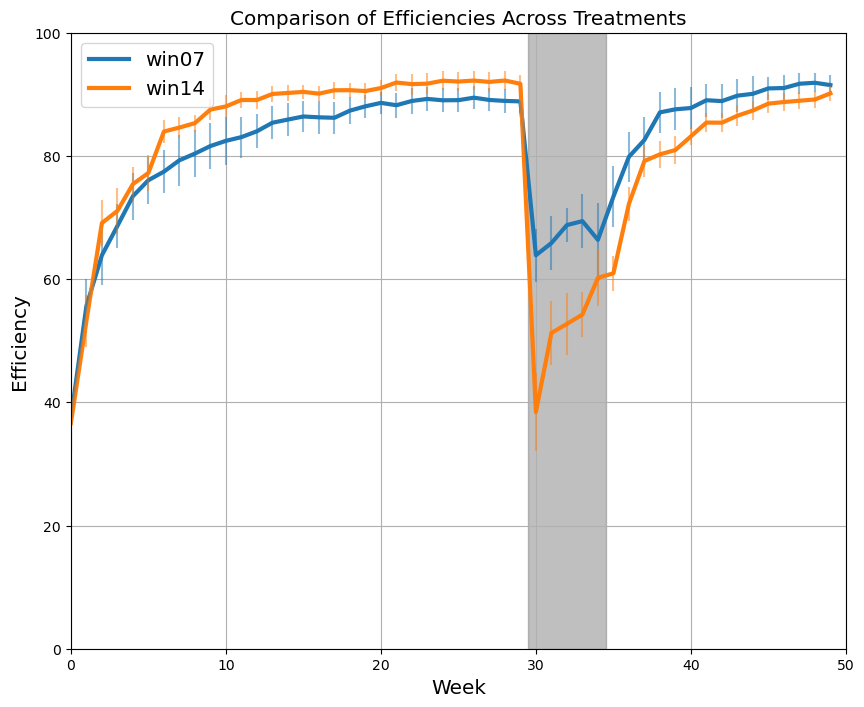

In [ ]:
import copy
strategy_params14_2 = copy.deepcopy(strategy_params14)
strategy_params07_2 = copy.deepcopy(strategy_params7)
strategy_params14_2.update({'reset_flag_min_trades':2})
strategy_params07_2.update({'reset_flag_min_trades':2})

mc_treats = {
    'win14_2': {'strategy_params':strategy_params14_2},
    'win07_2': {'strategy_params':strategy_params07_2},
}


dir3_try = dm_sim_experiment.make_experiment(sim_vars=mc_params, 
                                  treatment_dict=mc_treats, treatment_names=list(mc_treats), 
                                  return_period_df=False, includes_event=True, print_params=False)

exp3_eff, exp_class, exp_group = dm_utils.summary_surplus(dir3_try)
dm_utils.plot_comp_efficiencies(exp3_eff, shadow=True, event_bars=(event_begin, event_end))

{'win07_1': [[10, 'BUYER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, (500, 0), None, 0, None], [10, 'SELLER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, (500, 0), None, 0, None]], 'win07_2': [[10, 'BUYER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 7}, 200, 600, 8, (500, 0), None, 0, None], [10, 'SELLER', 'ZIDPA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 2, 'reset_flag_window': 7}, 200, 600, 8, (500, 0), None, 0, None]]}


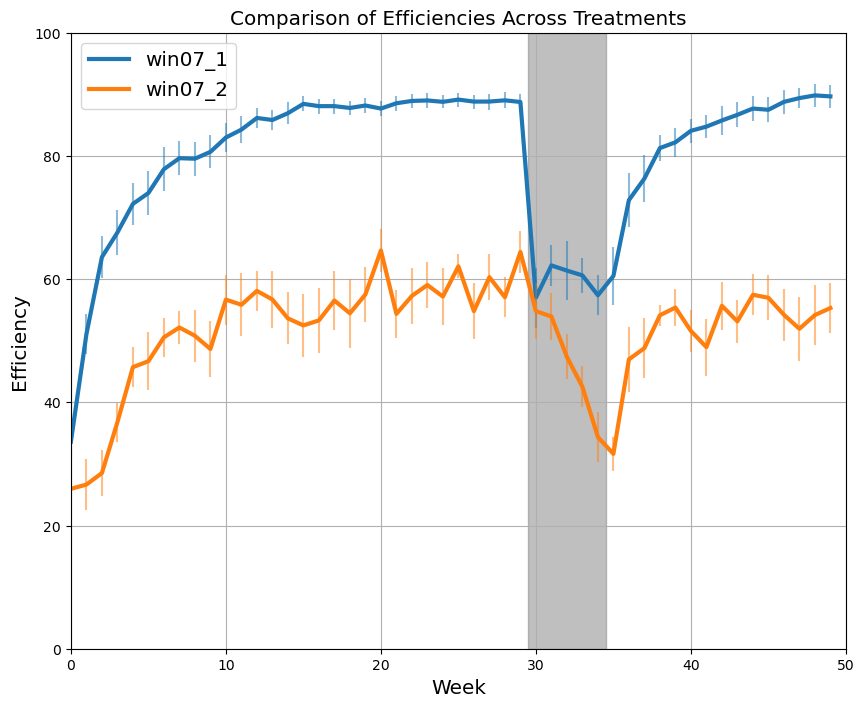

In [7]:
mc_treats = {
    'win07_1': {'strategy_params':strategy_params7},
    'win07_2': {'strategy_params':strategy_params07_2},
}


dir4_try = dm_sim_experiment.make_experiment(sim_vars=mc_params, 
                                  treatment_dict=mc_treats, treatment_names=list(mc_treats), 
                                  return_period_df=False, includes_event=True, print_params=False)

exp4_eff, exp_class, exp_group = dm_utils.summary_surplus(dir4_try)
dm_utils.plot_comp_efficiencies(exp4_eff, shadow=True, event_bars=(event_begin, event_end))

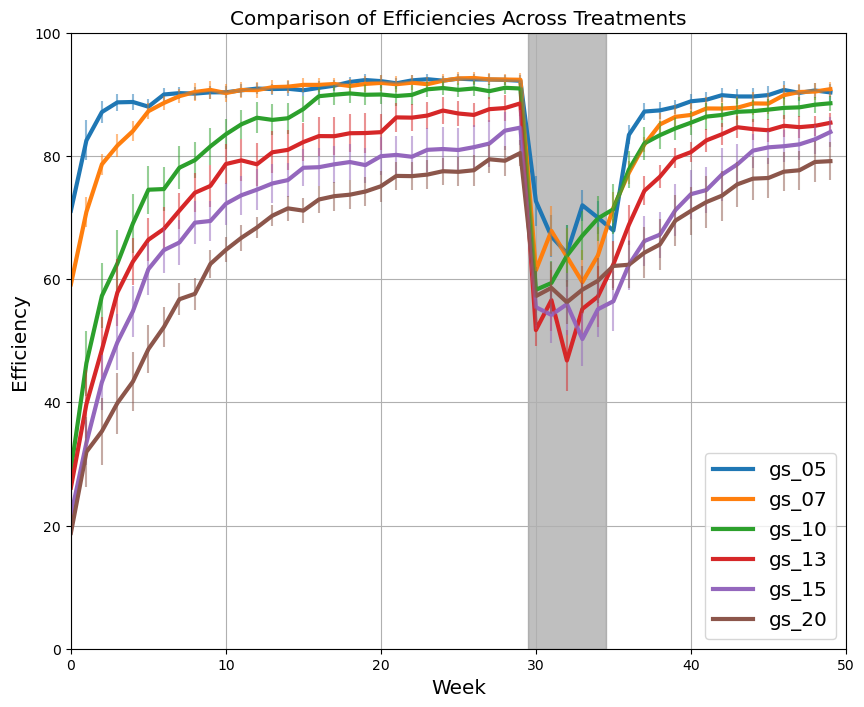

In [13]:
mc_treats = {
    'win07_1': {'strategy_params':strategy_params7},
    'win07_2': {'strategy_params':strategy_params07_2},
}

base2_agents = dm_utils.gen_agent_groups(num_agents=10, 
                          agent_type=['BUYER', 'SELLER'],
                          agent_class='ZIDPA', 
                          strategy_params= {'reset_flag_frequency':'WINDOW',
                                            'reset_flag_min_trades': 1,
                                            'reset_flag_window': 7
                                            },
                          lower_bound=200, 
                          upper_bound=600, 
                          num_units=8, 
                          endowment=(500, 0), 
                          payoff_function=None, 
                          move_error_rate=0, 
                          starting_location=None, 
                          return_names=False)

mc2_params = copy.deepcopy(mc_params)
mc2_params.update({'grid_size':None}) # Not strictly necessary - but best practice is to set the treatment variables to None for clarity
mc2_params.update({'agent_groups':base2_agents})

mc2_treats = {
    'gs_05': {'grid_size': 5},
    'gs_07': {'grid_size': 7},
    'gs_10': {'grid_size': 10},
    'gs_13': {'grid_size': 13},
    'gs_15': {'grid_size': 15},
    'gs_20': {'grid_size': 20}}

gs_tests = dm_sim_experiment.make_experiment(sim_vars=mc2_params, 
                                  treatment_dict=mc2_treats, treatment_names=list(mc2_treats), 
                                  return_period_df=False, includes_event=True, print_params=False)

gs_eff, exp_class, exp_group = dm_utils.summary_surplus(gs_tests)
dm_utils.plot_comp_efficiencies(gs_eff, shadow=True, event_bars=(event_begin, event_end))

In [15]:
# Compare homogenous and nonhomogenous agents

# Define number of agents in 
n_agents=10

# Define agent types
ag_types = ["BUYER"]*3+["SELLER"]*3

# Define agent class behavior 
ag_class='ZIDPA'
sp= {'reset_flag_frequency':'WINDOW',
    'reset_flag_min_trades': 1,
    'reset_flag_window': 7
    }

# Define custom group names
ag_names = []
ends = ['low', 'med', 'high']
for i in range(len(ag_types)):
    ag_names.append(ag_types[i]+ends[i%3])

# Define value bounds
lb=[100, 200, 300]*2
ub=[500, 600, 700]*2

n_units=8

# Endowment - this is never used in our analysis so far (only care about surplus) so ignoring
ws=0

# Using defaults for payoffs, mer, starting location
pfx=None
mer=0
loc=None

# Generate the groups
het_groups = dm_utils.gen_agent_groups(
    num_agents=n_agents, 
    agent_type=ag_types,
    agent_class=ag_class, 
    strategy_params=sp,
    lower_bound=lb, 
    upper_bound=ub, 
    num_units=n_units, 
    endowment=ws, 
    payoff_function=pfx, 
    move_error_rate=mer, 
    starting_location=loc)

hmg_groups = dm_utils.gen_agent_groups(
    num_agents=n_agents, 
    agent_type=ag_types,
    agent_class=ag_class, 
    strategy_params=sp,
    lower_bound=200, 
    upper_bound=600, 
    num_units=n_units, 
    endowment=ws, 
    payoff_function=pfx, 
    move_error_rate=mer, 
    starting_location=loc)

Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None],

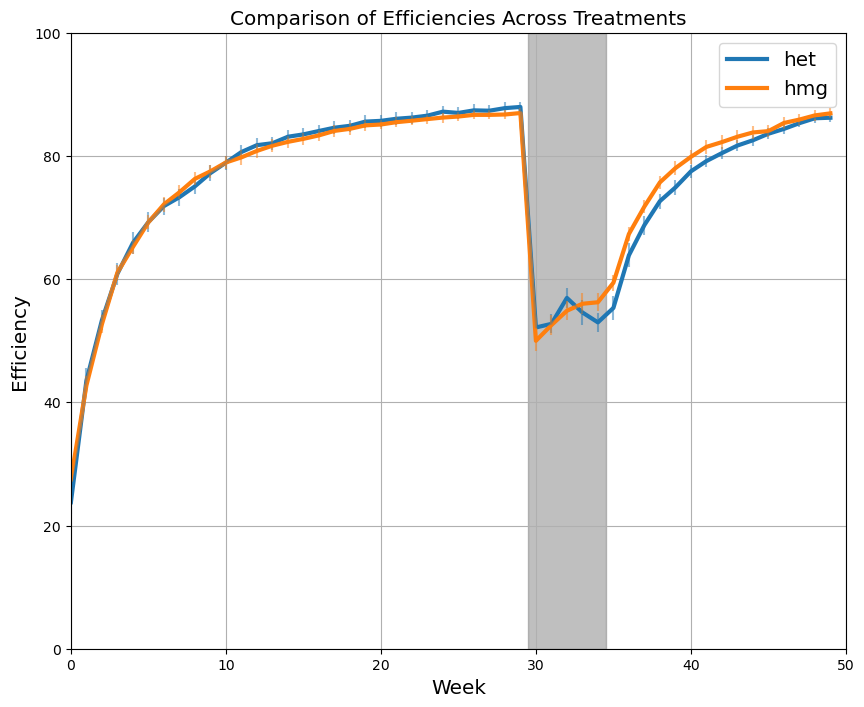

In [16]:
# Define treatments 
treat_vars = {
    'het': {'agent_groups': het_groups},
    'hmg': {'agent_groups': hmg_groups}
}

# Define other sim vars
base_vars = {
        'sim_name': 'test_het_agents',
        'num_trials': 25,
        'num_weeks': 50,
        'num_periods': 7,
        'num_rounds': 5,
        'num_traders': 60,
        'agent_groups': None,
        'grid_size': 20,
        'event_begin': 30,
        'event_end': 35,
        'new_agent_class': 'ZIDPR',
        'new_strategy_params': None,
        'new_movement_error_rate': None,
        'group_names': ag_names
}

het_test = dm_sim_experiment.make_event_experiment(sim_vars=base_vars,
                                        treatment_dict=treat_vars,
                                        treatment_names=list(treat_vars),
                                        return_period_df=False, print_params=False)

het_eff, exp_class, exp_group = dm_utils.summary_surplus(het_test)
dm_utils.plot_comp_efficiencies(het_eff, shadow=True, event_bars=(30, 35))

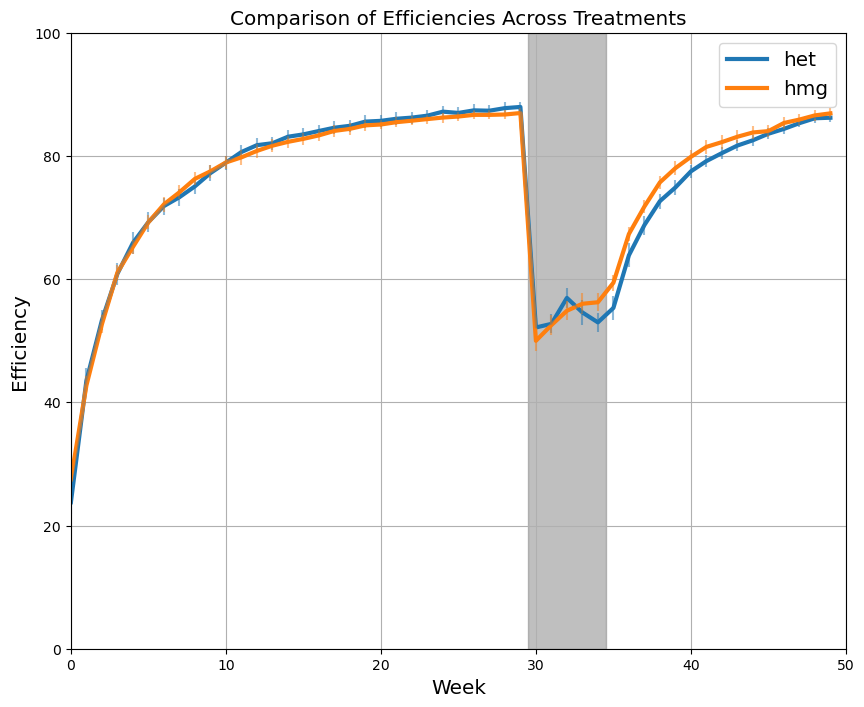

In [17]:
het_eff, exp_class, exp_group = dm_utils.summary_surplus(het_test)
dm_utils.plot_comp_efficiencies(het_eff, shadow=True, event_bars=(30, 35))

In [ ]:
base_vars.update({"grid_size":30})
het_test = dm_sim_experiment.make_event_experiment(sim_vars=base_vars,
                                        treatment_dict=treat_vars,
                                        treatment_names=list(treat_vars),
                                        return_period_df=False, print_params=False)

het_eff, exp_class, exp_group = dm_utils.summary_surplus(het_test)
dm_utils.plot_comp_efficiencies(het_eff, shadow=True, event_bars=(30, 35))

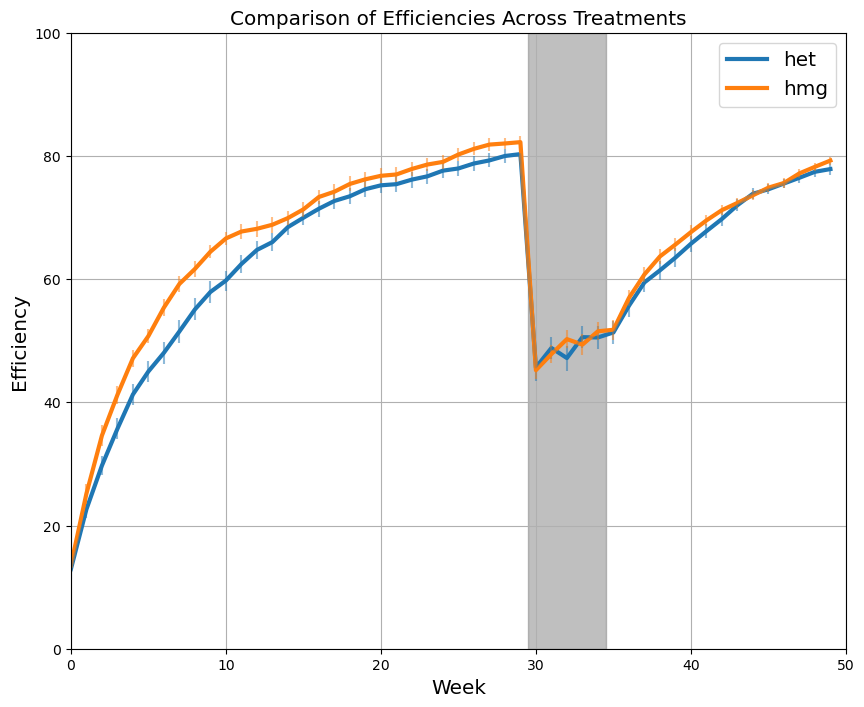

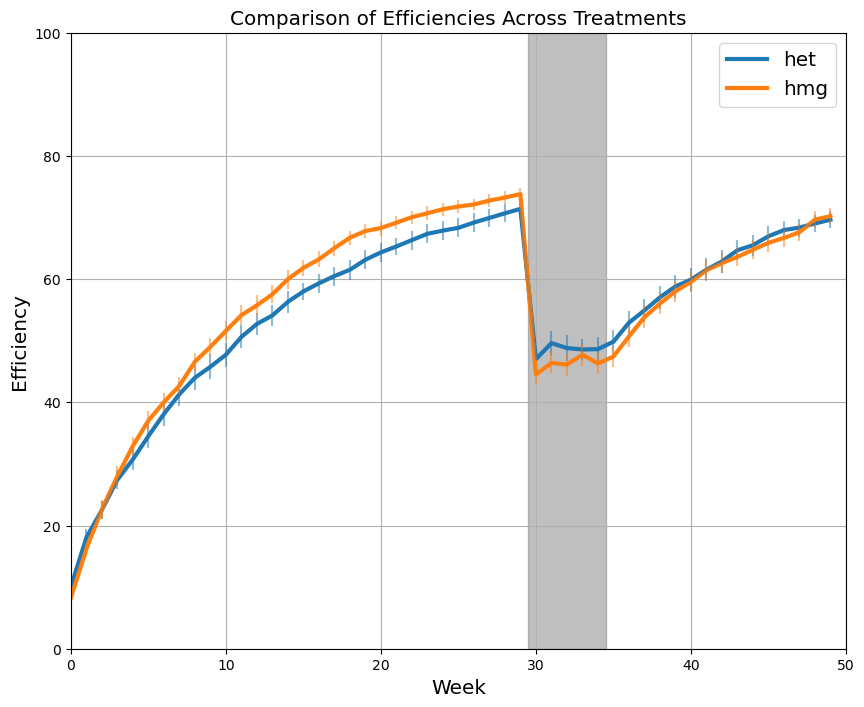

In [26]:
base_vars.update({"grid_size":40})
het_test = dm_sim_experiment.make_event_experiment(sim_vars=base_vars,
                                        treatment_dict=treat_vars,
                                        treatment_names=list(treat_vars),
                                        return_period_df=False, print_params=False)

het_eff, exp_class, exp_group = dm_utils.summary_surplus(het_test)
dm_utils.plot_comp_efficiencies(het_eff, shadow=True, event_bars=(30, 35))

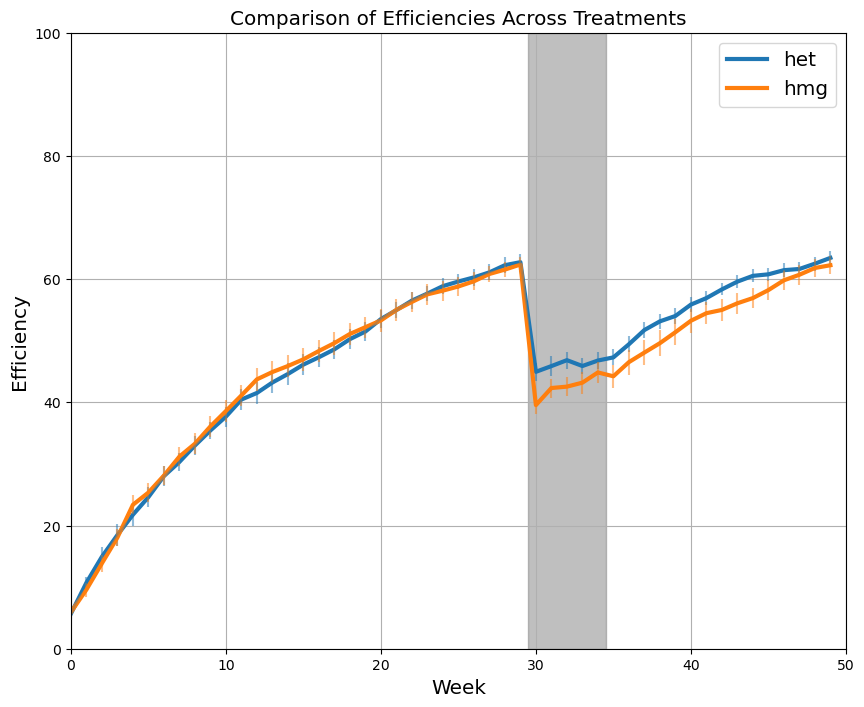

In [27]:
base_vars.update({"grid_size":50})
het_test = dm_sim_experiment.make_event_experiment(sim_vars=base_vars,
                                        treatment_dict=treat_vars,
                                        treatment_names=list(treat_vars),
                                        return_period_df=False, print_params=False)

het_eff, exp_class, exp_group = dm_utils.summary_surplus(het_test)
dm_utils.plot_comp_efficiencies(het_eff, shadow=True, event_bars=(30, 35))

In [ ]:
# Test agent_groups from dictionary
# Define number of agents in 
n_agents=10

# Define agent types
ag_types = ["BUYER"]*3+["SELLER"]*3

# Define agent class behavior 
ag_class='ZIDPA'
sp= {'reset_flag_frequency':'WINDOW',
    'reset_flag_min_trades': 1,
    'reset_flag_window': 7
    }

# Define custom group names
ag_names = []
ends = ['low', 'med', 'high']
for i in range(len(ag_types)):
    ag_names.append(ag_types[i]+ends[i%3])

# Define value bounds
lb=[000, 200, 400]*2
ub=[600, 800, 1000]*2

n_units=8

# Endowment - this is never used in our analysis so far (only care about surplus) so ignoring
ws=0

# Using defaults for payoffs, mer, starting location
pfx=None
mer=0
loc=None

het_ag_vars = {
    'num_agents': n_agents, 
    'agent_type': ag_types,
    'agent_class': ag_class, 
    'strategy_params': sp,
    'lower_bound': lb, 
    'upper_bound': ub, 
    'num_units': n_units, 
    'endowment': ws, 
    'payoff_function': pfx, 
    'move_error_rate': mer, 
    'starting_location': loc
}

het_ag_groups = dm_utils.agents_from_dict(het_ag_vars, return_names=False)

hm_ag_vars = copy.deepcopy(het_ag_vars)
hm_ag_vars.update({'lower_bound':lb[1], 'upper_bound':ub[1]})
hm_ag_groups = dm_utils.agents_from_dict(hm_ag_vars, return_names=False)

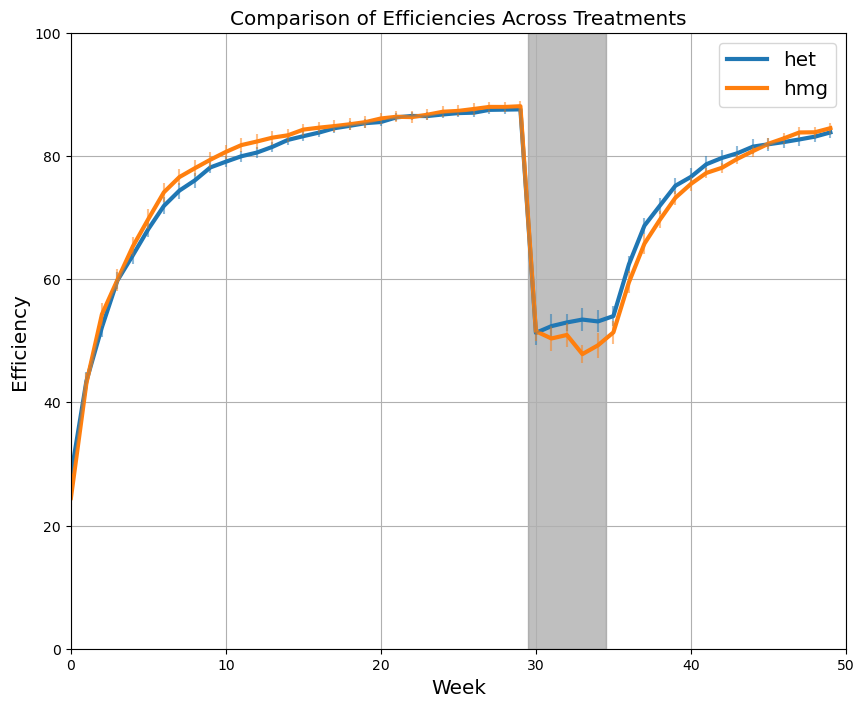

In [13]:
# Define treatments 
treat_vars = {
    'het': {'agent_groups': het_ag_groups},
    'hmg': {'agent_groups': hm_ag_groups}
}

# Define other sim vars
base_vars = {
        'sim_name': 'test_het_agents',
        'num_trials': 25,
        'num_weeks': 50,
        'num_periods': 7,
        'num_rounds': 5,
        'num_traders': 60,
        'agent_groups': None,
        'grid_size': 20,
        'event_begin': 30,
        'event_end': 35,
        'new_agent_class': 'ZIDPR',
        'new_strategy_params': None,
        'new_movement_error_rate': None,
        'group_names': ag_names
}

base_vars.update({"grid_size":20})
het_test = dm_sim_experiment.make_event_experiment(sim_vars=base_vars,
                                        treatment_dict=treat_vars,
                                        treatment_names=list(treat_vars),
                                        return_period_df=False, print_params=False)

het_eff, exp_class, exp_group = dm_utils.summary_surplus(het_test)
dm_utils.plot_comp_efficiencies(het_eff, shadow=True, event_bars=(30, 35))

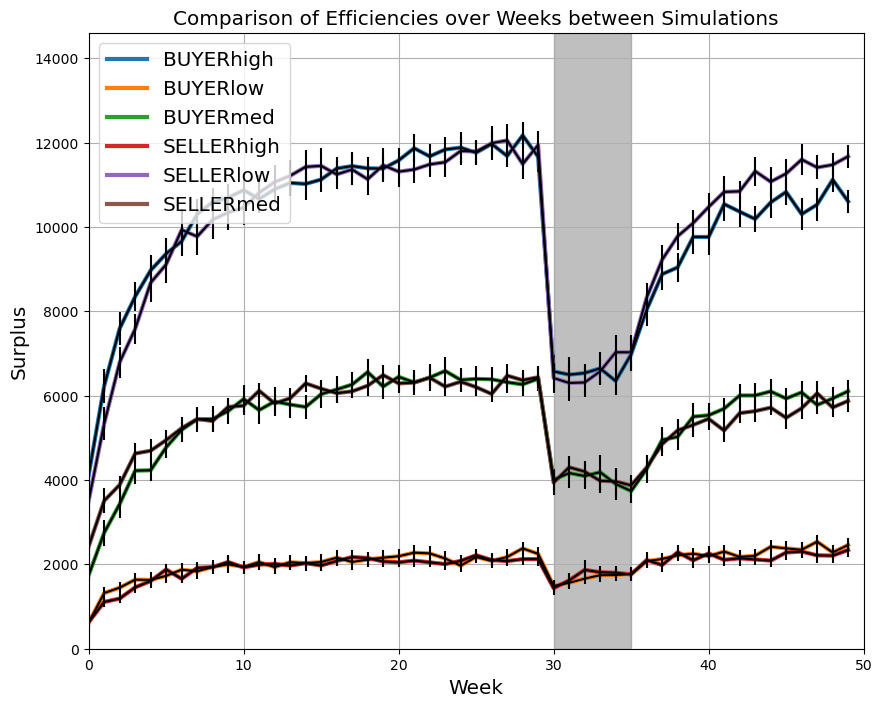

In [14]:
dm_utils.graph_summary(exp_group[exp_group['treatment']=='het'], by='agent_group', title=None, event_bars=(30, 35))

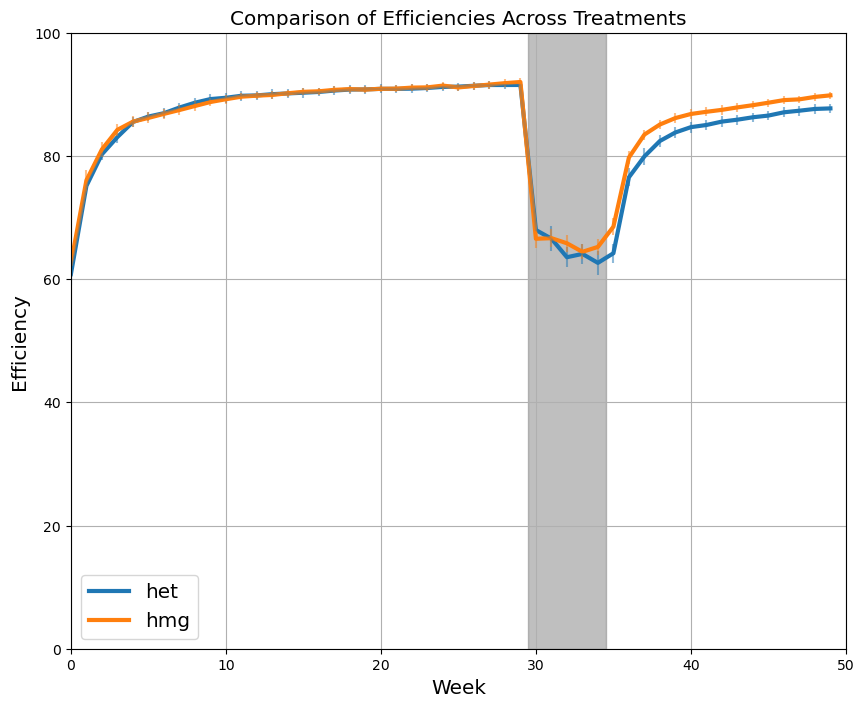

In [16]:
# Test agent_groups from dictionary
# Define number of agents in 
n_agents=20

# Define agent class behavior 
ag_class='ZIDPA'
sp= {'reset_flag_frequency':'WINDOW',
    'reset_flag_min_trades': 1,
    'reset_flag_window': 7
    }

# Define custom group names
ag_names = None

n_units=8

# Endowment - this is never used in our analysis so far (only care about surplus) so ignoring
ws=0

# Using defaults for payoffs, mer, starting location
pfx=None
mer=0
loc=None

base_ag_vars = {
    'num_agents': None,
    'agent_type': None,
    'agent_class': ag_class, 
    'strategy_params': sp,
    'lower_bound': None, 
    'upper_bound': None,
    'num_units': n_units, 
    'endowment': ws, 
    'payoff_function': pfx, 
    'move_error_rate': mer, 
    'starting_location': loc
}

# Excess sellers
buyer_vars = copy.deepcopy(base_ag_vars)
buyer_vars.update({
    'num_agents': 5,
    'agent_type': "BUYER",
    'lower_bound': 200, 
    'upper_bound': 600,
})
buy_ag_gr = dm_utils.agents_from_dict(buyer_vars, return_names=False)

seller_vars = copy.deepcopy(base_ag_vars)
seller_vars.update({
    'num_agents': 15,
    'agent_type': "SELLER",
    'lower_bound': 200, 
    'upper_bound': 600,
})
sell_ag_gr = dm_utils.agents_from_dict(seller_vars, return_names=False)

ex_sellers = copy.deepcopy(buy_ag_gr + sell_ag_gr)

# Even groups
buyer_vars.update({
    'num_agents': 10,
    'agent_type': "BUYER",
    'lower_bound': 200, 
    'upper_bound': 600,
})
seller_vars.update({
    'num_agents': 10,
    'agent_type': "SELLER",
    'lower_bound': 200, 
    'upper_bound': 600,
})
buy_ag_gr = dm_utils.agents_from_dict(buyer_vars, return_names=False)
sell_ag_gr = dm_utils.agents_from_dict(seller_vars, return_names=False)
even_gr = copy.deepcopy(buy_ag_gr + sell_ag_gr)

# Excess buyers
buyer_vars.update({
    'num_agents': 15,
    'agent_type': "BUYER",
    'lower_bound': 200, 
    'upper_bound': 600,
})
seller_vars.update({
    'num_agents': 5,
    'agent_type': "SELLER",
    'lower_bound': 200, 
    'upper_bound': 600,
})
buy_ag_gr = dm_utils.agents_from_dict(buyer_vars, return_names=False)
sell_ag_gr = dm_utils.agents_from_dict(seller_vars, return_names=False)
ex_buyers = copy.deepcopy(buy_ag_gr + sell_ag_gr)

treat_dict = {
    'ex_sellers': {'agent_groups':ex_sellers},
    'evens': {'agent_groups':even_gr},
    'ex_buyers': {'agent_groups':ex_buyers},
}

# Define other sim vars
base_vars = {
        'sim_name': 'test_het_agents',
        'num_trials': 25,
        'num_weeks': 50,
        'num_periods': 7,
        'num_rounds': 5,
        'num_traders': 60,
        'agent_groups': None,
        'grid_size': 10,
        'event_begin': 30,
        'event_end': 35,
        'new_agent_class': 'ZIDPR',
        'new_strategy_params': None,
        'new_movement_error_rate': None,
        'group_names': ag_names
}

het_test = dm_sim_experiment.make_event_experiment(sim_vars=base_vars,
                                        treatment_dict=treat_vars,
                                        treatment_names=list(treat_vars),
                                        return_period_df=False, print_params=False)

het_eff, exp_class, exp_group = dm_utils.summary_surplus(het_test)
dm_utils.plot_comp_efficiencies(het_eff, shadow=True, event_bars=(30, 35))

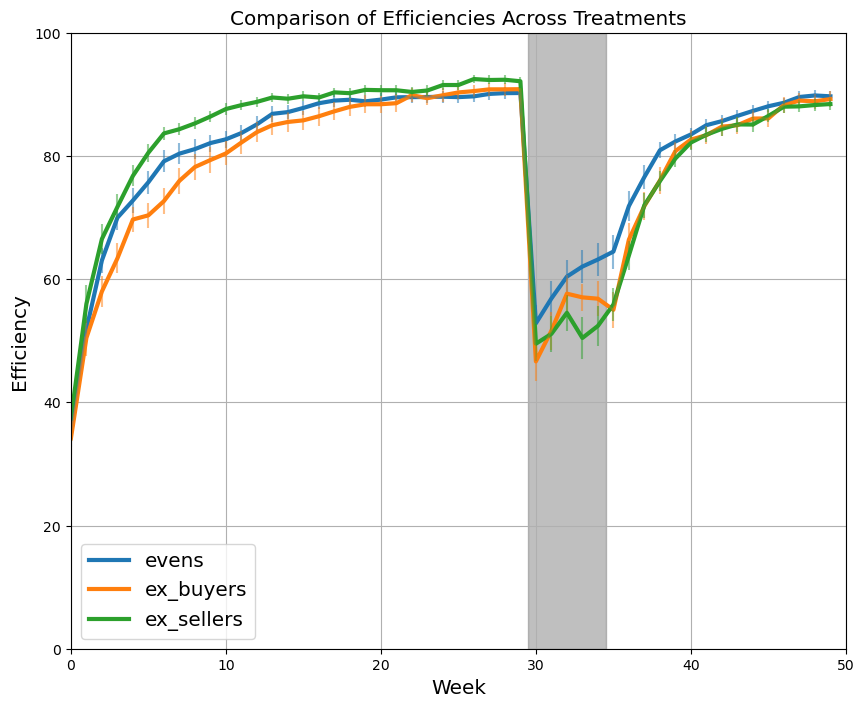

In [17]:
het_test = dm_sim_experiment.make_event_experiment(sim_vars=base_vars,
                                        treatment_dict=treat_dict,
                                        treatment_names=list(treat_dict),
                                        return_period_df=False, print_params=False)

het_eff, exp_class, exp_group = dm_utils.summary_surplus(het_test)
dm_utils.plot_comp_efficiencies(het_eff, shadow=True, event_bars=(30, 35))

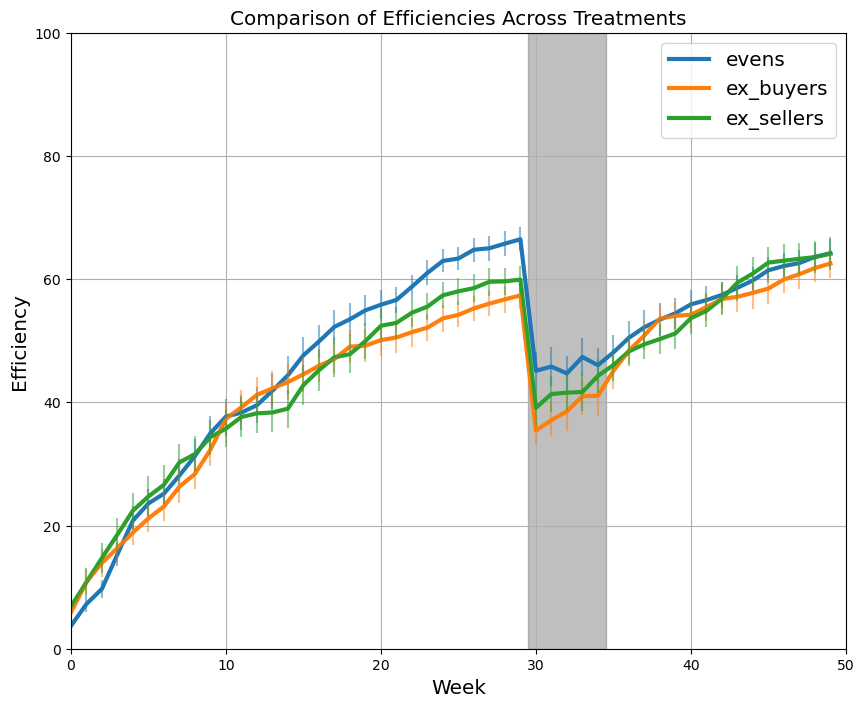

In [18]:
base_vars.update({"grid_size":30})
het_test = dm_sim_experiment.make_event_experiment(sim_vars=base_vars,
                                        treatment_dict=treat_dict,
                                        treatment_names=list(treat_dict),
                                        return_period_df=False, print_params=False)

het_eff, exp_class, exp_group = dm_utils.summary_surplus(het_test)
dm_utils.plot_comp_efficiencies(het_eff, shadow=True, event_bars=(30, 35))

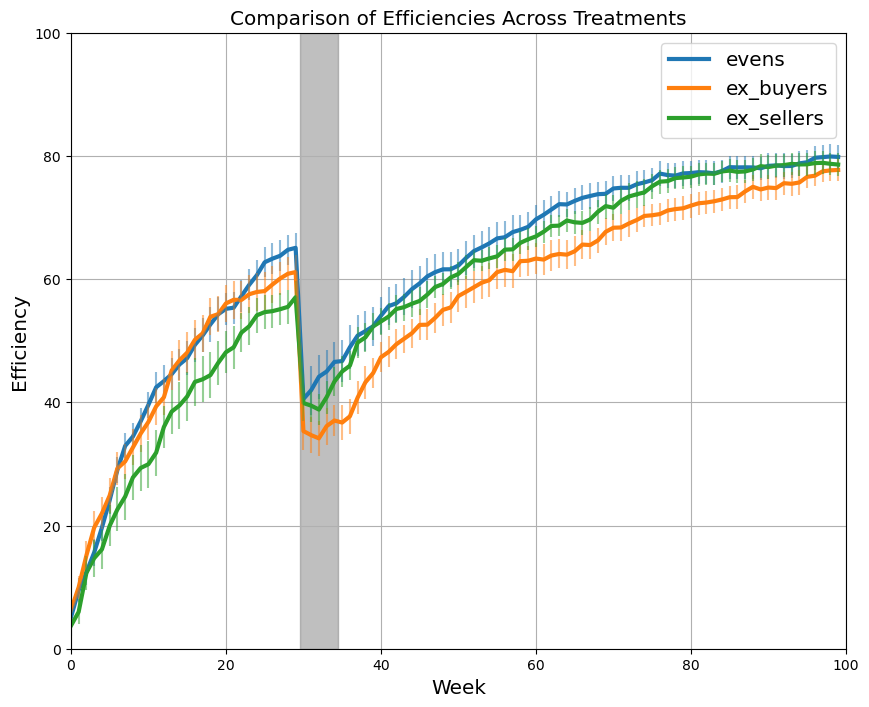

In [19]:
base_vars.update({"grid_size":30,
                  'num_weeks':100})
het_test = dm_sim_experiment.make_event_experiment(sim_vars=base_vars,
                                        treatment_dict=treat_dict,
                                        treatment_names=list(treat_dict),
                                        return_period_df=False, print_params=False)

het_eff, exp_class, exp_group = dm_utils.summary_surplus(het_test)
dm_utils.plot_comp_efficiencies(het_eff, shadow=True, event_bars=(30, 35))

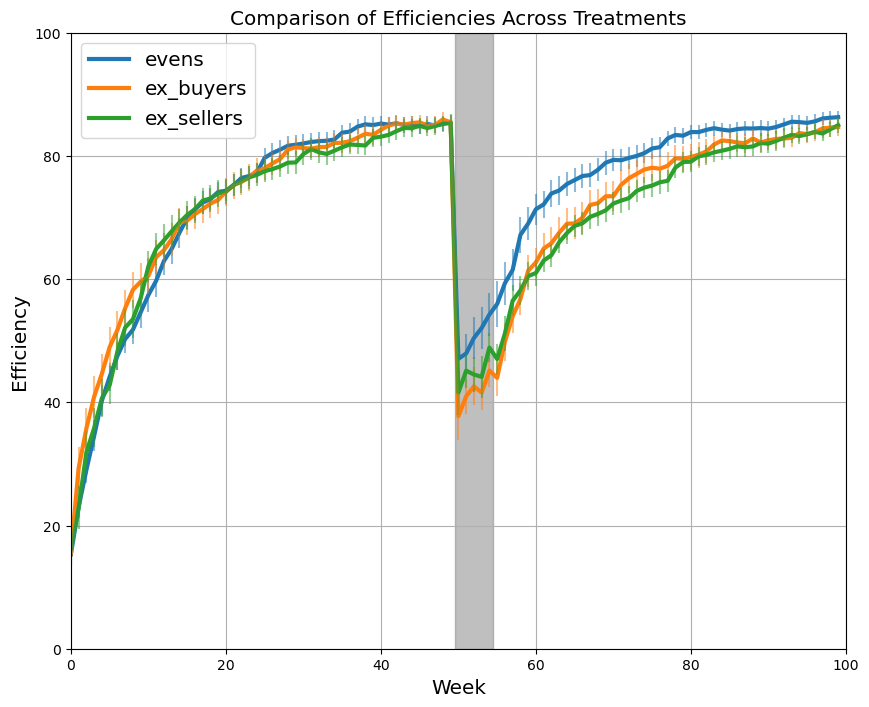

In [20]:
base_vars.update({"grid_size":20,
                  'num_weeks':100,
                  'event_begin':50,
                  'event_end':55})
het_test = dm_sim_experiment.make_event_experiment(sim_vars=base_vars,
                                        treatment_dict=treat_dict,
                                        treatment_names=list(treat_dict),
                                        return_period_df=False, print_params=False)

het_eff, exp_class, exp_group = dm_utils.summary_surplus(het_test)
dm_utils.plot_comp_efficiencies(het_eff, shadow=True, event_bars=(50, 55))

Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None],

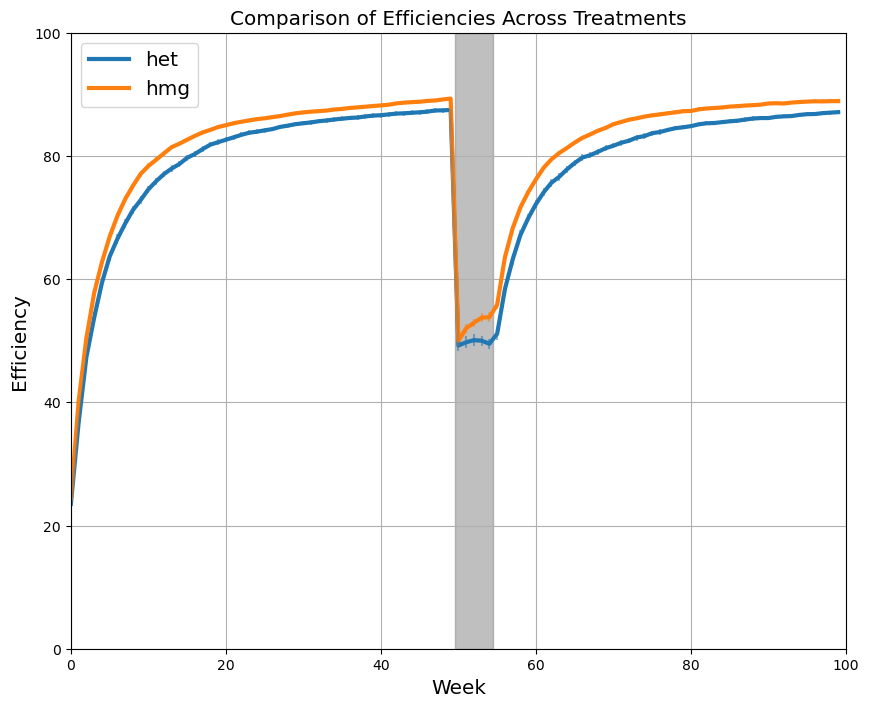

In [18]:
# Test agent_groups from dictionary
# Define number of agents in 
n_agents=50

# Define agent types
ag_types = ["BUYER"]*3+["SELLER"]*3

# Define agent class behavior 
ag_class='ZIDPA'
sp= {'reset_flag_frequency':'WINDOW',
    'reset_flag_min_trades': 1,
    'reset_flag_window': 7
    }

# Define custom group names
ag_names = []
ends = ['low', 'med', 'high']
for i in range(len(ag_types)):
    ag_names.append(ag_types[i]+ends[i%3])

# Define value bounds
lb=[000, 200, 400]*2
ub=[600, 800, 1000]*2

n_units=8

# Endowment - this is never used in our analysis so far (only care about surplus) so ignoring
ws=0

# Using defaults for payoffs, mer, starting location
pfx=None
mer=0
loc=None

het_ag_vars = {
    'num_agents': n_agents,
    'agent_type': ag_types, 
    'num_agents': n_agents, 
    'agent_type': ag_types,
    'agent_class': ag_class, 
    'strategy_params': sp,
    'lower_bound': lb, 
    'upper_bound': ub, 
    'num_units': n_units, 
    'endowment': ws, 
    'payoff_function': pfx, 
    'move_error_rate': mer, 
    'starting_location': loc
}

het_ag_groups = dm_utils.agents_from_dict(het_ag_vars, return_names=False)

hm_ag_vars = copy.deepcopy(het_ag_vars)
hm_ag_vars.update({'lower_bound':lb[1], 'upper_bound':ub[1]})
hm_ag_groups = dm_utils.agents_from_dict(hm_ag_vars, return_names=False)

treat_dict = {
    'hmg': {'agent_groups':hm_ag_groups},
    'het': {'agent_groups':het_ag_groups},
}

# Define other sim vars
base_vars = {
        'sim_name': 'test_het_agents_big',
        'num_trials': 25,
        'num_weeks': 100,
        'num_periods': 7,
        'num_rounds': 5,
        'num_traders': 300,
        'agent_groups': None,
        'grid_size': 50,
        'event_begin': 50,
        'event_end': 55,
        'new_agent_class': 'ZIDPR',
        'new_strategy_params': None,
        'new_movement_error_rate': None,
        'group_names': ag_names
}

het_test = dm_sim_experiment.make_event_experiment(sim_vars=base_vars,
                                        treatment_dict=treat_dict,
                                        treatment_names=list(treat_dict),
                                        return_period_df=False, print_params=False)

het_eff, exp_class, exp_group = dm_utils.summary_surplus(het_test)
dm_utils.plot_comp_efficiencies(het_eff, shadow=True, event_bars=(50, 55))

In [ ]:
het_test = dm_sim_experiment.make_event_experiment(sim_vars=base_vars,
                                        treatment_dict=treat_dict,
                                        treatment_names=list(treat_dict),
                                        return_period_df=False, print_params=False)

het_eff, exp_class, exp_group = dm_utils.summary_surplus(het_test)
dm_utils.plot_comp_efficiencies(het_eff, shadow=True, event_bars=(50, 55))

Moving to: [['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None], ['ZIDPR', None, None],

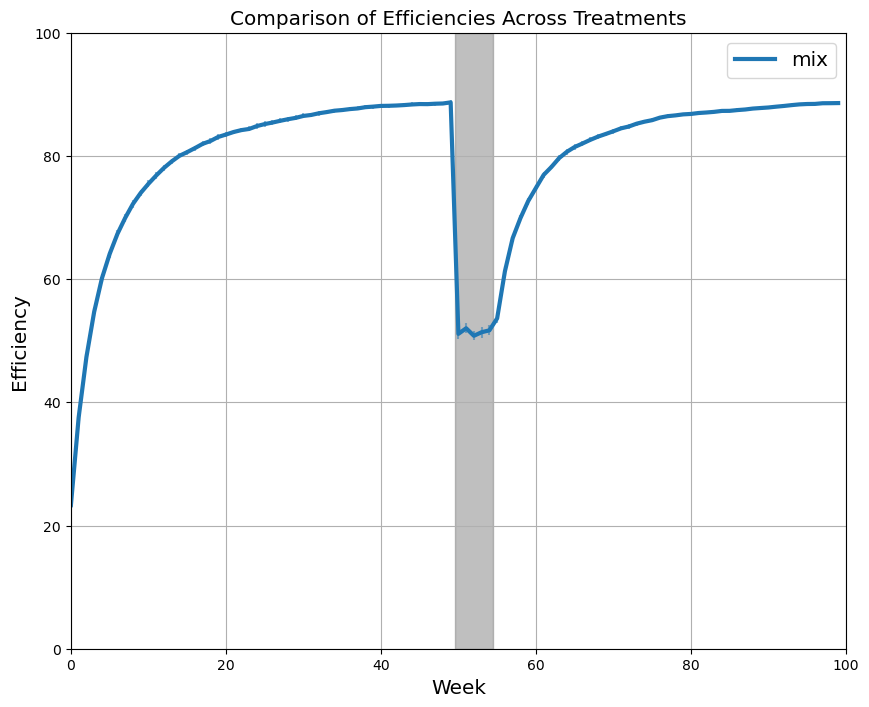

In [20]:
# Test agent_groups from dictionary
# Define number of agents in 
n_agents=25

# Define agent types
ag_types = ["BUYER"]*3+["SELLER"]*3

# Define agent class behavior 
ag_class='ZIDPA'
sp= {'reset_flag_frequency':'WINDOW',
    'reset_flag_min_trades': 1,
    'reset_flag_window': 7
    }

# Define custom group names
ag_names = ['BUYER_HMG']*3+['SELLER_HMG']*3
ends = ['low', 'med', 'high']
for i in range(len(ag_types)):
    ag_names.append(ag_types[i]+ends[i%3])

# Define value bounds
lb=[000, 200, 400]*2
ub=[600, 800, 1000]*2

n_units=8

# Endowment - this is never used in our analysis so far (only care about surplus) so ignoring
ws=0

# Using defaults for payoffs, mer, starting location
pfx=None
mer=0
loc=None

het_ag_vars = {
    'num_agents': n_agents,
    'agent_type': ag_types, 
    'num_agents': n_agents, 
    'agent_type': ag_types,
    'agent_class': ag_class, 
    'strategy_params': sp,
    'lower_bound': lb, 
    'upper_bound': ub, 
    'num_units': n_units, 
    'endowment': ws, 
    'payoff_function': pfx, 
    'move_error_rate': mer, 
    'starting_location': loc
}

het_ag_groups = dm_utils.agents_from_dict(het_ag_vars, return_names=False)

hm_ag_vars = copy.deepcopy(het_ag_vars)
hm_ag_vars.update({'lower_bound':lb[1], 'upper_bound':ub[1]})
hm_ag_groups = dm_utils.agents_from_dict(hm_ag_vars, return_names=False)

treat_dict = {
    'mix': {},
}

# Define other sim vars
base_vars = {
        'sim_name': 'test_het_agents_big',
        'num_trials': 25,
        'num_weeks': 100,
        'num_periods': 7,
        'num_rounds': 5,
        'num_traders': 300,
        'agent_groups':hm_ag_groups+het_ag_groups,
        'grid_size': 50,
        'event_begin': 50,
        'event_end': 55,
        'new_agent_class': 'ZIDPR',
        'new_strategy_params': None,
        'new_movement_error_rate': None,
        'group_names': ag_names
}

het_test = dm_sim_experiment.make_event_experiment(sim_vars=base_vars,
                                        treatment_dict=treat_dict,
                                        treatment_names=list(treat_dict),
                                        return_period_df=False, print_params=False)

het_eff, exp_class, exp_group = dm_utils.summary_surplus(het_test)
dm_utils.plot_comp_efficiencies(het_eff, shadow=True, event_bars=(50, 55))